# Reintegration Readiness

This notebook is one of the required IS 455 machine learning pipelines for the INTEX project. It is written to be executable top to bottom and to tell the complete story from business framing through deployment notes.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
pipeline_dir = repo_root / "ml-pipelines"
if not pipeline_dir.exists() and repo_root.name == "ml-pipelines":
    pipeline_dir = repo_root
    repo_root = repo_root.parent
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

import common_utils as cu

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# 1. Problem Framing

**Business problem.** Which residents appear most ready for reintegration or placement in the near future?

**Who cares.** Case managers, social workers, and leadership using the Residents and Reports pages care about this because they need a consistent readiness lens across safehouses.

**Why it matters to the website and the case.** This pipeline supports the deployed Bella Porto Foundation experience by turning raw data into decisions that staff or donors can actually use in the application. That aligns with the IS 455 rubric, which requires complete pipeline thinking rather than an algorithm in isolation.

**Predictive vs explanatory framing.** This notebook is explicitly **both**, and it includes both an explanatory model and a predictive model because those solve different decisions.

The explanatory classifier helps staff understand which observed patterns travel with successful reintegration records. The predictive classifier turns those patterns into a readiness score that can surface residents who may be ready for more active planning conversations.

**Target definition.** Because the dataset is retrospective, the target is a documented proxy: `readiness_flag` equals 1 for residents whose observed record ended in completed reintegration or a closed placement outcome. The model is then used as a present-day readiness ranking tool, not as a guarantee of future success.


In [2]:
bundle = cu.prepare_reintegration_readiness_dataset()
df = bundle["data"].copy()
feature_cols = bundle["feature_cols"]
numeric_cols = bundle["numeric_cols"]
categorical_cols = bundle["categorical_cols"]

print("Dataset shape:", df.shape)
print("Feature columns:", len(feature_cols))
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
display(df.head())

for label, target in [("Explanatory target", bundle["explanatory_target"]), ("Predictive target", bundle["predictive_target"])]:
    if target in df.columns:
        print(f"\n{label}: {target}")
        display(df[target].describe(include="all"))


Dataset shape: (60, 108)
Feature columns: 34
Numeric columns: 29
Categorical columns: 5


,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,is_pwd,pwd_type,has_special_needs,special_needs_diagnosis,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,date_of_admission,age_upon_admission,present_age,length_of_stay,referral_source,referring_agency_person,date_colb_registered,date_colb_obtained,assigned_social_worker,initial_case_assessment,date_case_study_prepared,reintegration_type,reintegration_status,initial_risk_level,current_risk_level,date_enrolled,date_closed,created_at,notes_restricted,age_at_admission_months,...,education_progress_percent_mean,education_progress_percent_delta,education_record_count,education_last_date,health_general_health_score_latest,health_general_health_score_mean,health_general_health_score_delta,health_nutrition_score_latest,health_nutrition_score_mean,health_nutrition_score_delta,health_sleep_quality_score_latest,health_sleep_quality_score_mean,health_sleep_quality_score_delta,health_energy_level_score_latest,health_energy_level_score_mean,health_energy_level_score_delta,health_bmi_latest,health_bmi_mean,health_bmi_delta,health_record_count,health_last_date,visit_count_total,visit_count_180d,visit_favorable_share,visit_safety_concern_rate,visit_follow_up_rate,visit_family_cooperation_mean,visit_days_since_last,process_sessions_total,process_sessions_90d,process_concern_rate,process_progress_rate,process_referral_rate,process_mean_duration,process_emotion_shift_mean,process_days_since_last,plan_count_total,plan_completed_share,plan_in_progress_share,plan_category_diversity,plan_target_value_mean,plan_days_since_update,incident_total_count,incident_recent_180d,incident_high_severity_count,incident_unresolved_count,incident_followup_required_count,incident_mean_severity,incident_days_since_last,readiness_flag
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,Neglected,False,False,False,False,False,False,False,False,False,False,False,NaN,True,Speech Impairment,False,False,False,False,False,2023-10-17,15 Years 9 months,17 Years 6 months,2 Years 4 months,NGO,Ramon Cruz,NaN,NaN,SW-15,For Reunification,2023-12-14,Foster Care,In Progress,Critical,High,2023-10-17,NaT,2023-10-17,NaN,189.0,...,45.483333,15.1,6,2024-03-01,3.22,3.103333,0.13,3.39,3.210000,0.37,3.20,3.203333,0.02,2.91,2.908333,0.01,15.8,15.583333,0.3,6,2024-03-01,54.0,0.0,0.333333,0.166667,0.500000,0.296296,344.0,106,0,0.235849,0.924528,0.160377,69.433962,1.801887,363,3,0.0,0.333333,3,3.083333,1068,4.0,0.0,1.0,1.0,1.0,1.750000,357.0,0
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,Surrendered,False,False,False,False,False,False,False,True,True,False,False,NaN,False,NaN,False,False,True,False,False,2023-03-18,15 Years 5 months,17 Years 10 months,1 Years 9 months,Government Agency,Ana Cruz,2023-07-06,2024-12-30,SW-14,For Continued Care,2023-04-10,Family Reunification,Completed,Medium,Medium,2023-03-18,2025-01-06,2023-03-18,NaN,185.0,...,85.230000,33.2,10,2023-12-01,3.62,3.449000,0.43,3.67,3.431000,0.60,3.40,3.376000,0.16,3.08,3.001000,0.24,18.4,18.220000,0.1,10,2023-12-01,35.0,0.0,0.428571,0.314286,0.485714,0.114286,760.0,51,0,0.254902,0.921569,0.137255,68.176471,1.666667,776,3,0.0,0.000000,3,3.083333,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,Surrendered,False,False,False,False,True,False,False,False,False,False,False,NaN,False,NaN,False,False,False,False,False,2024-05-24,18 Years 3 months,19 Years 1 months,1 Years 9 months,Government Agency,NaN,2024-08-02,2024-09-21,SW-20,For Independent Living,NaN,Foster Care,Completed,Medium,Medium,2024-05-24,NaT,2024-05-24,NaN,219.0,...,71.581818,58.4,11,2025-03-01,3.57,3.18


Explanatory target: readiness_flag


count    60.000000
mean      0.466667
std       0.503098
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: readiness_flag, dtype: float64


Predictive target: readiness_flag


count    60.000000
mean      0.466667
std       0.503098
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: readiness_flag, dtype: float64

**Executive Takeaway.** The problem is framed as a real operating decision, not just a modeling exercise. The explanatory model helps the team reason about relationships, while the predictive model is reserved for scoring, ranking, or forecasting inside the website.


# 2. Data Acquisition, Preparation & Exploration

**Relevant tables and join logic.** `residents`, `education_records`, `health_wellbeing_records`, `home_visitations`, `intervention_plans`, `incident_reports`, and `process_recordings` are joined into a resident-level readiness dataset.

The preparation code below uses reusable pandas transformations and scikit-learn-compatible feature sets rather than one-off ad hoc cleaning. Missing values are handled explicitly by the modeling pipelines, while date parsing, aggregation grain, and proxy target construction are all documented in code.


,column,missing_share
0,incident_high_severity_count,0.266667
1,incident_unresolved_count,0.266667
2,incident_recent_180d,0.266667
3,visit_count_180d,0.033333
4,visit_favorable_share,0.033333
5,visit_safety_concern_rate,0.033333
6,visit_family_cooperation_mean,0.033333
7,safehouse_id,0.000000
8,process_concern_rate,0.000000
9,process_sessions_90d,0.000000


,safehouse_id,length_of_stay_months,present_age_months,education_progress_percent_latest,education_progress_percent_delta,education_attendance_rate_latest,readiness_flag
safehouse_id,1.000,0.061,-0.075,-0.066,0.003,0.102,-0.160
length_of_stay_months,0.061,1.000,-0.054,0.128,0.152,-0.077,-0.192
present_age_months,-0.075,-0.054,1.000,0.001,-0.149,-0.170,0.250
education_progress_percent_latest,-0.066,0.128,0.001,1.000,0.589,0.488,0.045
education_progress_percent_delta,0.003,0.152,-0.149,0.589,1.000,0.352,-0.109
education_attendance_rate_latest,0.102,-0.077,-0.170,0.488,0.352,1.000,0.110
readiness_flag,-0.160,-0.192,0.250,0.045,-0.109,0.110,1.000


Top categories for case_category:


,case_category,count
0,Surrendered,21
1,Abandoned,18
2,Foundling,11
3,Neglected,10


,feature,p01,median,p99
0,safehouse_id,1.00000,4.000,9.000
1,length_of_stay_months,6.59000,18.000,35.820
2,present_age_months,124.18000,202.000,243.000
3,education_progress_percent_latest,41.12000,100.000,100.000
4,education_progress_percent_delta,4.91100,47.850,80.576
5,education_attendance_rate_latest,0.51542,0.771,1.000


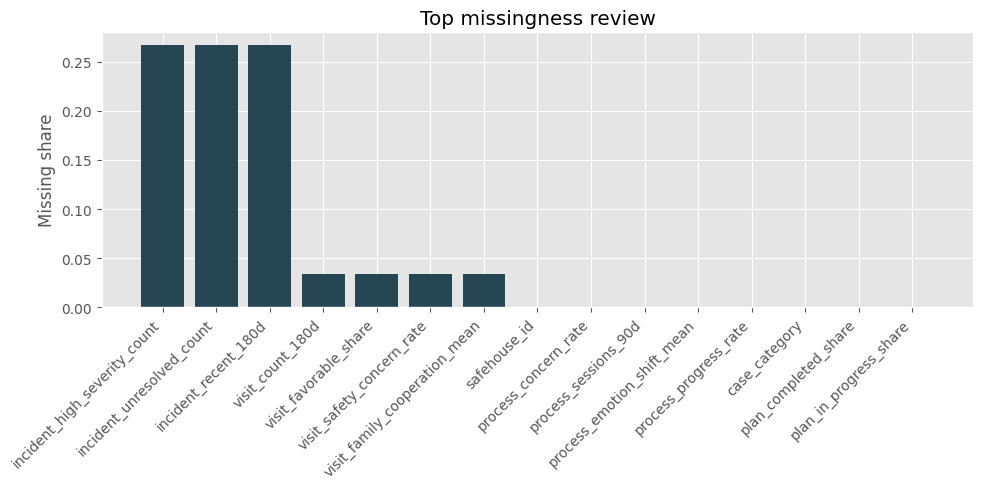

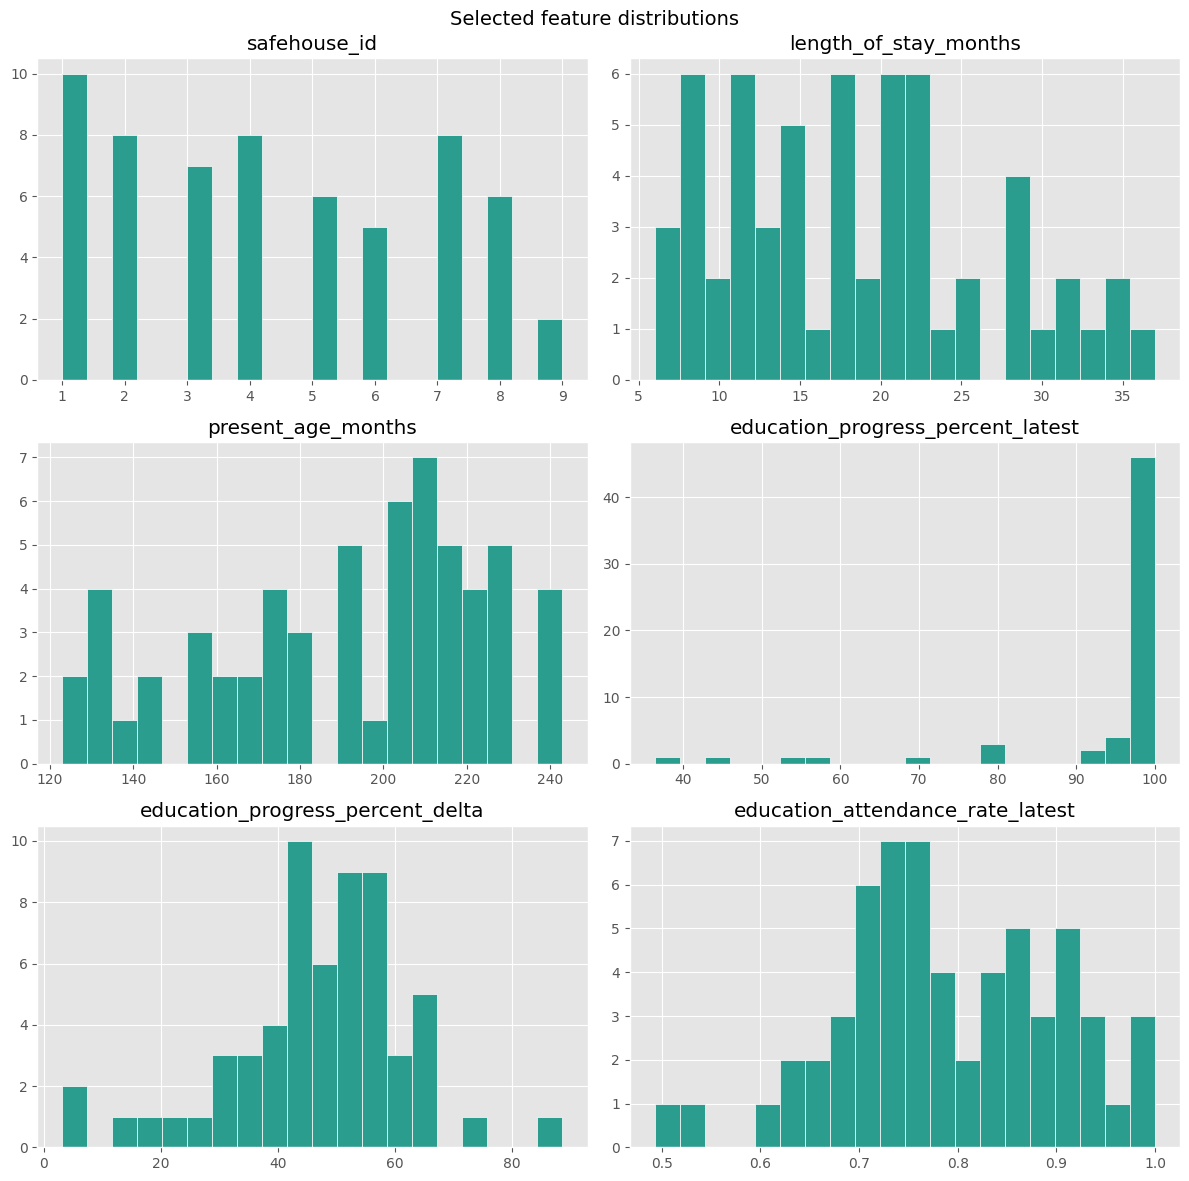

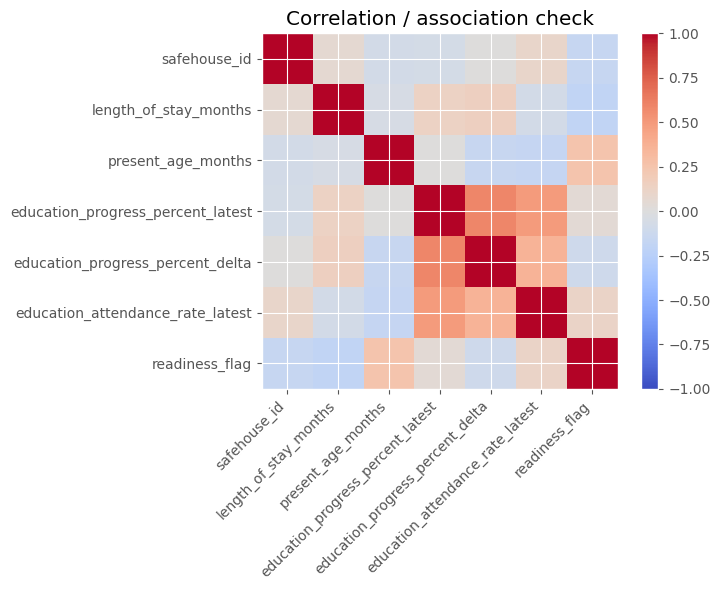

In [3]:
missing_table = cu.plot_missingness(df[feature_cols + [bundle["explanatory_target"], bundle["predictive_target"]]].copy(), "Top missingness review")
display(missing_table)

preview_numeric = [
    col
    for col in numeric_cols
    if col in df.columns and not pd.api.types.is_bool_dtype(df[col])
][:6]
if preview_numeric:
    cu.plot_numeric_overview(df, preview_numeric, "Selected feature distributions")

corr_candidates = [
    col
    for col in preview_numeric
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col])
]
if bundle["predictive_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["predictive_target"]]):
    corr_candidates = corr_candidates + [bundle["predictive_target"]]
elif bundle["explanatory_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["explanatory_target"]]):
    corr_candidates = corr_candidates + [bundle["explanatory_target"]]

corr_candidates = list(dict.fromkeys([col for col in corr_candidates if col in df.columns]))
if len(corr_candidates) >= 3:
    corr = cu.plot_correlation_heatmap(df, corr_candidates, "Correlation / association check")
    display(corr.round(3))

if categorical_cols:
    cat = categorical_cols[0]
    print(f"Top categories for {cat}:")
    display(
        df[cat]
        .fillna("Missing")
        .value_counts()
        .head(10)
        .rename("count")
        .reset_index()
        .rename(columns={"index": cat})
    )

outlier_review = pd.DataFrame({
    "feature": preview_numeric,
    "p01": [pd.to_numeric(df[col], errors="coerce").quantile(0.01) for col in preview_numeric],
    "median": [pd.to_numeric(df[col], errors="coerce").median() for col in preview_numeric],
    "p99": [pd.to_numeric(df[col], errors="coerce").quantile(0.99) for col in preview_numeric],
})
display(outlier_review)


**Executive Takeaway.** The exploration stage verifies that the target and candidate drivers are measurable, identifies missingness patterns early, and checks whether the dataset grain matches the decision being modeled. Outliers are kept visible and interpreted, rather than silently discarded.


# 3. Modeling & Feature Selection

The feature set deliberately favors operationally available columns over every possible field in the raw tables. That matters for two reasons:

1. The website can only score records with fields it actually stores and can refresh.
2. IS 455 expects feature selection to be justified instead of treating the dataset as a dumping ground.

The explanatory model is chosen for interpretability. The predictive model is chosen for stronger out-of-sample performance and non-linear pattern capture where appropriate.


In [4]:
explanatory_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["explanatory_target"],
    kind=bundle["explanatory_kind"],
    role="explanatory",
    time_col=bundle["time_col"],
)

predictive_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["predictive_target"],
    kind=bundle["predictive_kind"],
    role="predictive",
    time_col=bundle["time_col"],
)

print("Explanatory model metrics")
display(explanatory_results["metrics"])
print("Predictive model metrics")
display(predictive_results["metrics"])

print("Top explanatory features")
display(explanatory_results["feature_table"])
print("Top predictive features")
display(predictive_results["feature_table"])


Explanatory model metrics


,test_roc_auc,test_precision,test_recall,test_f1,test_log_loss,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,0.462963,0.5,0.333333,0.4,1.727289,0.446429,0.421429,0.42629,0.428571


Predictive model metrics


,test_roc_auc,test_precision,test_recall,test_f1,test_log_loss,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,0.351852,0.5,0.333333,0.4,0.813266,0.517857,0.353114,0.409524,0.321429


Top explanatory features


,feature,effect,abs_effect
0,num__process_concern_rate,0.893463,0.893463
1,cat__initial_risk_level_Medium,0.856411,0.856411
2,num__education_progress_percent_delta,-0.809386,0.809386
3,num__visit_favorable_share,-0.774778,0.774778
4,num__family_solo_parent,-0.705474,0.705474
5,num__education_attendance_rate_latest,0.672032,0.672032
6,num__family_is_4ps,0.641948,0.641948
7,num__family_indigenous,0.605255,0.605255
8,cat__current_risk_level_Low,0.582195,0.582195
9,cat__current_risk_level_High,-0.575013,0.575013


Top predictive features


,feature,effect,abs_effect
0,num__process_concern_rate,0.084900,0.084900
1,num__process_progress_rate,0.083292,0.083292
2,num__education_attendance_rate_latest,0.064524,0.064524
3,num__visit_family_cooperation_mean,0.060741,0.060741
4,num__health_general_health_score_latest,0.058295,0.058295
5,num__length_of_stay_months,0.052748,0.052748
6,num__visit_favorable_share,0.049913,0.049913
7,num__health_general_health_score_delta,0.043347,0.043347
8,num__present_age_months,0.043230,0.043230
9,num__health_sleep_quality_score_latest,0.041771,0.041771


**Executive Takeaway.** Feature selection is anchored in business logic first and model diagnostics second. The explanatory model clarifies directional relationships, and the predictive model tests whether additional flexibility improves operational usefulness enough to justify lower interpretability.


# 4. Evaluation & Interpretation

Proper validation matters because this organization will act on the outputs. The notebook therefore uses train/test logic with cross-validation summaries rather than evaluating only on the full sample.

**Real-world error tradeoff.** A false positive could push a resident toward a reintegration discussion before support systems are ready. A false negative keeps someone in a more restrictive setting longer than necessary.



Explanatory model holdout sample preview


,readiness_flag,prediction,score,split
0,1,0,0.386439,test
1,1,1,0.816127,test
2,1,1,0.809398,test
3,1,0,0.282086,test
4,1,1,0.558915,test
5,0,0,0.027415,test
6,0,0,0.025147,test
7,1,0,0.247511,test
8,1,0,0.025905,test
9,0,0,0.138617,test


Explanatory model confusion matrix


,pred_0,pred_1
actual_0,3,3
actual_1,6,3



Predictive model holdout sample preview


,readiness_flag,prediction,score,split
0,1,1,0.537422,test
1,1,0,0.463350,test
2,1,1,0.613023,test
3,1,0,0.436281,test
4,1,1,0.515096,test
5,0,0,0.421870,test
6,0,1,0.508888,test
7,1,0,0.326288,test
8,1,0,0.271412,test
9,0,0,0.415019,test


Predictive model confusion matrix


,pred_0,pred_1
actual_0,3,3
actual_1,6,3


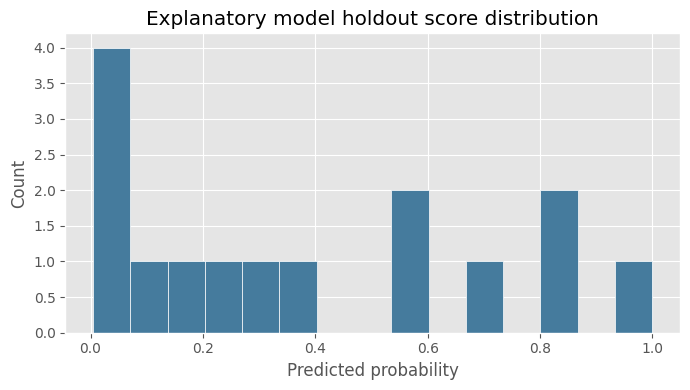

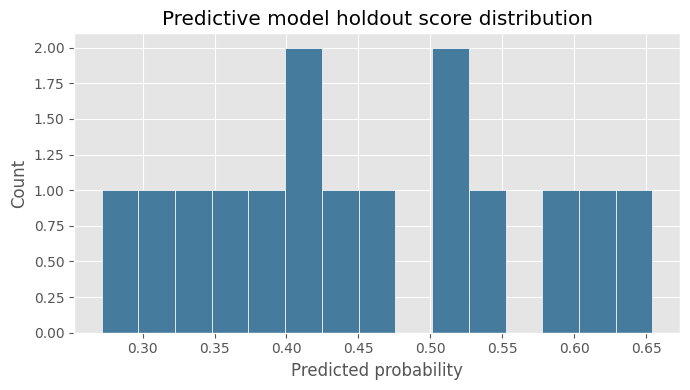

In [5]:
def show_model_diagnostics(label, results, kind, target_name):
    print(f"\n{label} holdout sample preview")
    display(results["holdout"].head(10))
    if kind == "classification":
        print(f"{label} confusion matrix")
        display(results["confusion_matrix"])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(results["holdout"]["score"], bins=15, color="#457b9d", edgecolor="white")
        ax.set_title(f"{label} holdout score distribution")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Count")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(results["holdout"][target_name], results["holdout"]["prediction"], alpha=0.75, color="#1d3557")
        lims = [
            np.nanmin([results["holdout"][target_name].min(), results["holdout"]["prediction"].min()]),
            np.nanmax([results["holdout"][target_name].max(), results["holdout"]["prediction"].max()]),
        ]
        ax.plot(lims, lims, linestyle="--", color="#e63946")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{label} actual vs predicted")
        plt.tight_layout()

show_model_diagnostics("Explanatory model", explanatory_results, bundle["explanatory_kind"], bundle["explanatory_target"])
show_model_diagnostics("Predictive model", predictive_results, bundle["predictive_kind"], bundle["predictive_target"])


**Executive Takeaway.** The evaluation section is intentionally honest. If the holdout performance is only moderate, that still has value as a prioritization aid as long as the notebook states the limitation clearly and keeps humans in the loop for high-stakes decisions.


# 5. Causal and Relationship Analysis

This section distinguishes what is **predictive** from what is plausibly **explanatory**.

Education and health progress, incident history, and family cooperation patterns are informative, but they do not prove a resident is causally ready. Staff judgment remains essential.

The tables below focus on the strongest modeled relationships while being careful not to equate feature importance with proof of causality.


In [6]:
relationship_target = bundle["predictive_target"] if bundle["predictive_kind"] == "regression" else bundle["explanatory_target"]
relationship_numeric = [col for col in numeric_cols if col in df.columns and df[col].notna().sum() > 5][:12]

if relationship_target in df.columns and pd.api.types.is_numeric_dtype(df[relationship_target]) and relationship_numeric:
    relationship_table = (
        df[relationship_numeric + [relationship_target]]
        .apply(pd.to_numeric, errors="coerce")
        .corr(numeric_only=True)[[relationship_target]]
        .sort_values(relationship_target, ascending=False)
    )
    display(relationship_table.round(3))

explanatory_top = explanatory_results["feature_table"].copy()
predictive_top = predictive_results["feature_table"].copy()
explanatory_top["model"] = "explanatory"
predictive_top["model"] = "predictive"
combined_top = pd.concat([explanatory_top, predictive_top], ignore_index=True)
display(combined_top)


,readiness_flag
readiness_flag,1.000
present_age_months,0.250
family_is_4ps,0.153
family_indigenous,0.120
education_attendance_rate_latest,0.110
education_progress_percent_latest,0.045
has_special_needs,0.022
health_general_health_score_latest,0.010
family_informal_settler,-0.019
education_progress_percent_delta,-0.109


,feature,effect,abs_effect,model
0,num__process_concern_rate,0.893463,0.893463,explanatory
1,cat__initial_risk_level_Medium,0.856411,0.856411,explanatory
2,num__education_progress_percent_delta,-0.809386,0.809386,explanatory
3,num__visit_favorable_share,-0.774778,0.774778,explanatory
4,num__family_solo_parent,-0.705474,0.705474,explanatory
5,num__education_attendance_rate_latest,0.672032,0.672032,explanatory
6,num__family_is_4ps,0.641948,0.641948,explanatory
7,num__family_indigenous,0.605255,0.605255,explanatory
8,cat__current_risk_level_Low,0.582195,0.582195,explanatory
9,cat__current_risk_level_High,-0.575013,0.575013,explanatory


**Executive Takeaway.** The strongest drivers in the models are useful for strategy discussions, but they should be interpreted as structured evidence rather than causal proof. In this project, observational data is valuable for prioritization and learning even when it cannot support hard causal claims.


# 6. Deployment Notes

**Website integration path.** Integrate the score into `/admin?tab=residents` as a readiness meter, show top drivers in the resident detail panel on the Caseload Inventory page, and summarize readiness distributions on `/admin?tab=reports`.

**Likely API surface.** A lightweight backend endpoint such as `/api/ml/reintegration-readiness` can score new records or refresh dashboard aggregates on a schedule.

**Implementation sketch.**

```python
# pseudocode used by the web app or backend job
record_batch = load_latest_records_from_database()
scored = model.predict_or_predict_proba(record_batch)
write_scores_back_to_reporting_table(scored)
refresh_dashboard_cards()
```

**Repository alignment.** The current application already has pages for admin dashboard, donations, residents, reports, outreach, and impact, so this pipeline is designed to plug into those existing navigation surfaces instead of inventing a disconnected demo experience.


**Executive Takeaway.** A notebook-only model is not enough for the rubric. The practical endpoint of this work is a score, forecast, or explanatory summary that appears in the deployed web app where staff and donors can actually use it.
